In [1]:
from ofdm.plots import plot_dataset_mapping
import torch
from nnscf import denormalize
import os
import time

In [2]:
raw_dir = "./raw dir/"
norm_dir = "./norm dir/"
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(norm_dir, exist_ok=True)

# Modulation scheme
mod = "16qam"
# mod = "qpsk"

# Clipping technique
# tech = "icf"
tech = "scf"

data_size = 100
train_size = 70
val_size = 10
test_size = data_size - train_size - val_size

params = f"{tech.upper()} {mod.upper()} (N=256, L=4, CR=6dB)"

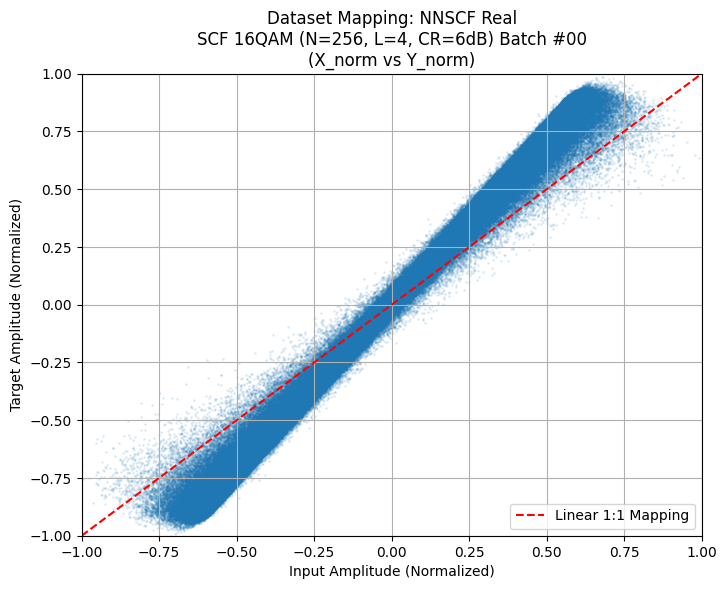

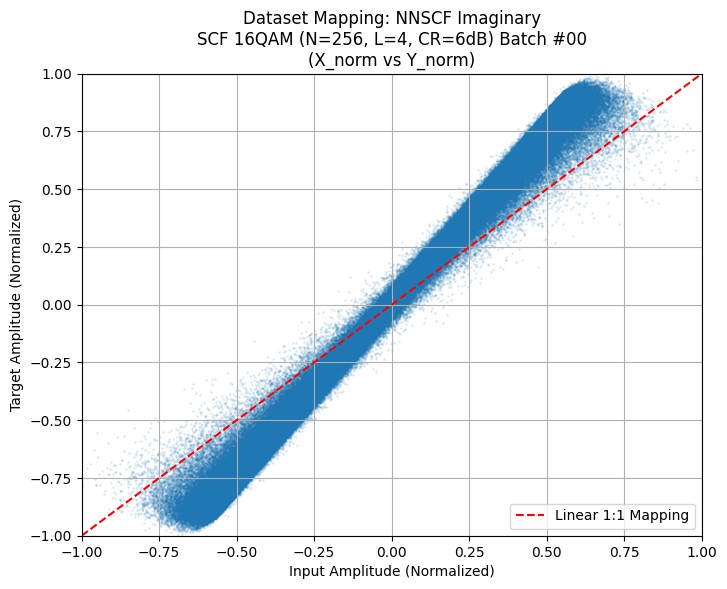

In [3]:
plot_dataset_mapping(os.path.join(raw_dir, f"{mod}_{tech}_part_{0:02d}_real.pt"), f"NN{tech.upper()} Real\n{params} Batch #{0:02d}")
plot_dataset_mapping(os.path.join(raw_dir, f"{mod}_{tech}_part_{0:02d}_imag.pt"), f"NN{tech.upper()} Imaginary\n{params} Batch #{0:02d}")

In [4]:
print("--- STEP 1: Finding Global Limits from Training Data (Files 0 to train_size - 1) ---")
# Initialize global trackers
g_X_r_min, g_X_r_max = float('inf'), float('-inf')
g_Y_r_min, g_Y_r_max = float('inf'), float('-inf')
g_X_i_min, g_X_i_max = float('inf'), float('-inf')
g_Y_i_min, g_Y_i_max = float('inf'), float('-inf')

--- STEP 1: Finding Global Limits from Training Data (Files 0 to train_size - 1) ---


In [5]:
# Only scan the first train_size files to prevent Data Leakage!
for i in range(train_size):
    # Load dictionaries
    data_real = torch.load(os.path.join(raw_dir, f"{mod}_{tech}_part_{i:02d}_real.pt"), weights_only=True)
    data_imag = torch.load(os.path.join(raw_dir, f"{mod}_{tech}_part_{i:02d}_imag.pt"), weights_only=True)

    # Extract local limits and update globals
    g_X_r_min = min(g_X_r_min, data_real['X_min'])
    g_X_r_max = max(g_X_r_max, data_real['X_max'])
    g_Y_r_min = min(g_Y_r_min, data_real['Y_min'])
    g_Y_r_max = max(g_Y_r_max, data_real['Y_max'])

    g_X_i_min = min(g_X_i_min, data_imag['X_min'])
    g_X_i_max = max(g_X_i_max, data_imag['X_max'])
    g_Y_i_min = min(g_Y_i_min, data_imag['Y_min'])
    g_Y_i_max = max(g_Y_i_max, data_imag['Y_max'])
    print(f"Found Local Real X Limits: Min = {data_real['X_min']:.4f}, Max = {data_real['X_max']:.4f}")

print(f"Found Global Real X Limits: Min = {g_X_r_min:.4f}, Max = {g_X_r_max:.4f}")

Found Local Real X Limits: Min = -0.2179, Max = 0.2225
Found Local Real X Limits: Min = -0.2243, Max = 0.2277
Found Local Real X Limits: Min = -0.2389, Max = 0.2295
Found Local Real X Limits: Min = -0.2234, Max = 0.2227
Found Local Real X Limits: Min = -0.2170, Max = 0.2419
Found Local Real X Limits: Min = -0.2211, Max = 0.2334
Found Local Real X Limits: Min = -0.2302, Max = 0.2524
Found Global Real X Limits: Min = -0.2389, Max = 0.2524


In [6]:
print(f"\n--- STEP 2: Denormalizing and Renormalizing ALL {data_size} Files ---")
before_loop = time.time()
for i in range(data_size):
    loop_start = time.time() if i else before_loop

    real_path_og = os.path.join(raw_dir, f"{mod}_{tech}_part_{i:02d}_real.pt")
    imag_path_og = os.path.join(raw_dir, f"{mod}_{tech}_part_{i:02d}_imag.pt")

    data_real = torch.load(real_path_og, weights_only=True)
    data_imag = torch.load(imag_path_og, weights_only=True)

    # --- PROCESS REAL ---
    # 1. Denormalize back to raw physical voltages
    raw_X_r = denormalize(data_real['X_norm'], (data_real['X_min'], data_real['X_max']))
    raw_Y_r = denormalize(data_real['Y_norm'], (data_real['Y_min'], data_real['Y_max']))

    # todo: maybe i could make a function for that
    # 2. Renormalize using Global Limits
    data_real['X_norm'] = 2.0 * ((raw_X_r - g_X_r_min) / (g_X_r_max - g_X_r_min)) - 1.0 if g_X_r_max != g_X_r_min else raw_X_r
    data_real['Y_norm'] = 2.0 * ((raw_Y_r - g_Y_r_min) / (g_Y_r_max - g_Y_r_min)) - 1.0 if g_Y_r_max != g_Y_r_min else raw_Y_r

    # 3. OVERWRITE the old local limits with the global limits in the dictionary!
    data_real['X_min'], data_real['X_max'] = g_X_r_min, g_X_r_max
    data_real['Y_min'], data_real['Y_max'] = g_Y_r_min, g_Y_r_max

    # --- PROCESS IMAGINARY ---
    raw_X_i = denormalize(data_imag['X_norm'], (data_imag['X_min'], data_imag['X_max']))
    raw_Y_i = denormalize(data_imag['Y_norm'], (data_imag['Y_min'], data_imag['Y_max']))

    # todo: maybe i could make a function for that
    data_imag['X_norm'] = 2.0 * ((raw_X_i - g_X_i_min) / (g_X_i_max - g_X_i_min)) - 1.0 if g_X_i_max != g_X_i_min else raw_X_i
    data_imag['Y_norm'] = 2.0 * ((raw_Y_i - g_Y_i_min) / (g_Y_i_max - g_Y_i_min)) - 1.0 if g_Y_i_max != g_Y_i_min else raw_Y_i

    data_imag['X_min'], data_imag['X_max'] = g_X_i_min, g_X_i_max
    data_imag['Y_min'], data_imag['Y_max'] = g_Y_i_min, g_Y_i_max

    real_path_out = os.path.join(norm_dir, f"{mod}_{tech}_part_{i:02d}_real.pt")
    imag_path_out = os.path.join(norm_dir, f"{mod}_{tech}_part_{i:02d}_imag.pt")

    # Save files back to disk (overwriting)
    torch.save(data_real, real_path_out)
    torch.save(data_imag, imag_path_out)

    loop_end = time.time()
    print(f"Iteration {i + 1}/{data_size} completed in {loop_end - loop_start:.2f} seconds")
    print(f"{loop_end - before_loop:.2f} seconds passed since before loop start")

print("Data successfully updated with Global Normalization!")


--- STEP 2: Denormalizing and Renormalizing ALL 10 Files ---
Iteration 1/10 completed in 0.45 seconds
0.45 seconds passed since before loop start
Iteration 2/10 completed in 0.44 seconds
0.90 seconds passed since before loop start
Iteration 3/10 completed in 0.42 seconds
1.32 seconds passed since before loop start
Iteration 4/10 completed in 0.42 seconds
1.73 seconds passed since before loop start
Iteration 5/10 completed in 0.44 seconds
2.17 seconds passed since before loop start
Iteration 6/10 completed in 0.41 seconds
2.58 seconds passed since before loop start
Iteration 7/10 completed in 0.49 seconds
3.08 seconds passed since before loop start
Iteration 8/10 completed in 0.57 seconds
3.65 seconds passed since before loop start
Iteration 9/10 completed in 0.58 seconds
4.23 seconds passed since before loop start
Iteration 10/10 completed in 0.52 seconds
4.74 seconds passed since before loop start
Data successfully updated with Global Normalization!


In [7]:
for i in range(train_size):
    # Load dictionaries
    data_real = torch.load(os.path.join(norm_dir, f"{mod}_{tech}_part_{i:02d}_real.pt"), weights_only=True)
    data_imag = torch.load(os.path.join(norm_dir, f"{mod}_{tech}_part_{i:02d}_imag.pt"), weights_only=True)

    # Extract local limits and update globals
    g_X_r_min = min(g_X_r_min, data_real['X_min'])
    g_X_r_max = max(g_X_r_max, data_real['X_max'])
    g_Y_r_min = min(g_Y_r_min, data_real['Y_min'])
    g_Y_r_max = max(g_Y_r_max, data_real['Y_max'])

    g_X_i_min = min(g_X_i_min, data_imag['X_min'])
    g_X_i_max = max(g_X_i_max, data_imag['X_max'])
    g_Y_i_min = min(g_Y_i_min, data_imag['Y_min'])
    g_Y_i_max = max(g_Y_i_max, data_imag['Y_max'])
    print(f"Found Local Real X Limits: Min = {g_X_r_min:.4f}, Max = {g_X_r_max:.4f}")

print(f"Found Global Real X Limits: Min = {g_X_r_min:.4f}, Max = {g_X_r_max:.4f}")

Found Local Real X Limits: Min = -0.2389, Max = 0.2524
Found Local Real X Limits: Min = -0.2389, Max = 0.2524
Found Local Real X Limits: Min = -0.2389, Max = 0.2524
Found Local Real X Limits: Min = -0.2389, Max = 0.2524
Found Local Real X Limits: Min = -0.2389, Max = 0.2524
Found Local Real X Limits: Min = -0.2389, Max = 0.2524
Found Local Real X Limits: Min = -0.2389, Max = 0.2524
Found Global Real X Limits: Min = -0.2389, Max = 0.2524


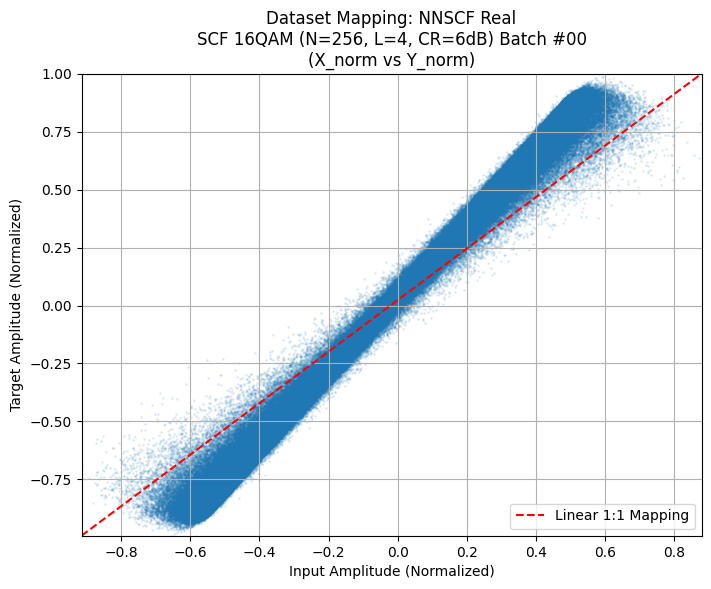

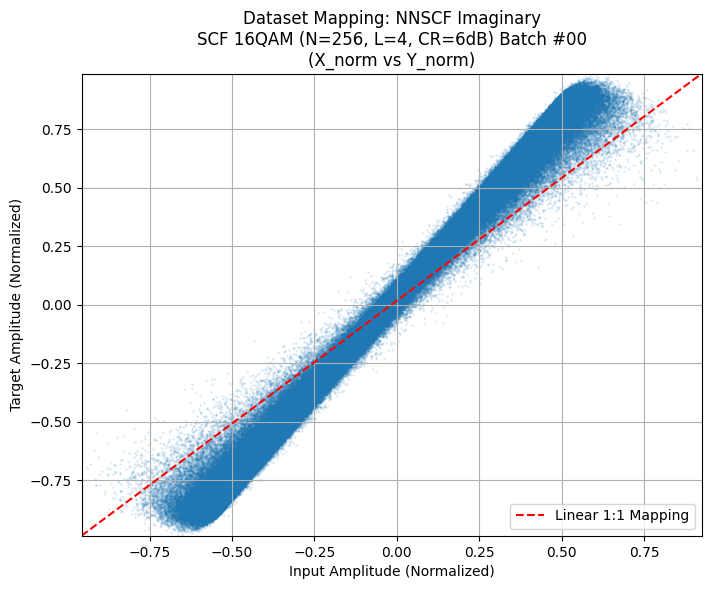

In [8]:
plot_dataset_mapping(os.path.join(norm_dir, f"{mod}_{tech}_part_{0:02d}_real.pt"), f"NN{tech.upper()} Real\n{params} Batch #{0:02d}")
plot_dataset_mapping(os.path.join(norm_dir, f"{mod}_{tech}_part_{0:02d}_imag.pt"), f"NN{tech.upper()} Imaginary\n{params} Batch #{0:02d}")